## **Spacy Word Vector (Text Representation)**

In [1]:
import spacy

# word vectors occupy lot of space. hence en_core_web_sm model do not have them included. 
# In order to download
# word vectors you need to install large or medium english model. We will install the large one!
# make sure you have run "python -m spacy download en_core_web_lg" to install large english model
nlp = spacy.load("en_core_web_lg")

In [2]:
doc = nlp("dog cat banana Lakshya") # Spacy en_web_core_lg model has already trained and have vectors for some 
    # Known words but The new words will give us OOV(Out of Vocabulary)

for token in doc:
    print(token.text,"Has Vector : ",token.has_vector,"OOV: ",token.is_oov)

dog Has Vector :  True OOV:  False
cat Has Vector :  True OOV:  False
banana Has Vector :  True OOV:  False
Lakshya Has Vector :  False OOV:  True


In [3]:
print("Shape : ",doc[0].vector.shape) # The shape of vector of "dog" is 300 
print(doc[0].text)
print(doc[0].vector)

Shape :  (300,)
dog
[-4.0176e-01  3.7057e-01  2.1281e-02 -3.4125e-01  4.9538e-02  2.9440e-01
 -1.7376e-01 -2.7982e-01  6.7622e-02  2.1693e+00 -6.2691e-01  2.9106e-01
 -6.7270e-01  2.3319e-01 -3.4264e-01  1.8311e-01  5.0226e-01  1.0689e+00
  1.4698e-01 -4.5230e-01 -4.1827e-01 -1.5967e-01  2.6748e-01 -4.8867e-01
  3.6462e-01 -4.3403e-02 -2.4474e-01 -4.1752e-01  8.9088e-02 -2.5552e-01
 -5.5695e-01  1.2243e-01 -8.3526e-02  5.5095e-01  3.6410e-01  1.5361e-01
  5.5738e-01 -9.0702e-01 -4.9098e-02  3.8580e-01  3.8000e-01  1.4425e-01
 -2.7221e-01 -3.7016e-01 -1.2904e-01 -1.5085e-01 -3.8076e-01  4.9583e-02
  1.2755e-01 -8.2788e-02  1.4339e-01  3.2537e-01  2.7226e-01  4.3632e-01
 -3.1769e-01  7.9405e-01  2.6529e-01  1.0135e-01 -3.3279e-01  4.3117e-01
  1.6687e-01  1.0729e-01  8.9418e-02  2.8635e-01  4.0117e-01 -3.9222e-01
  4.5217e-01  1.3521e-01 -2.8878e-01 -2.2819e-02 -3.4975e-01 -2.2996e-01
  2.0224e-01 -2.1177e-01  2.7184e-01  9.1703e-02 -2.0610e-01 -6.5758e-01
  1.8949e-01 -2.6756e-01  9.263

In [4]:
base_token = nlp("bread")

print(base_token.vector.shape) # Here we do not write base_token[0] as normally base_token represents sentence_vector and their is only one word in the sentence

(300,)


In [6]:
doc = nlp("bread sandwich burger car tiger human wheat butter")  # Now checking that our base_token 
#i.e. bread is How much similiar to these words in the document

for token in doc:
    print(f"{token.text} <--> {base_token} : Similiarity : {token.similarity(base_token)}")

bread <--> bread : Similiarity : 1.0
sandwich <--> bread : Similiarity : 0.6874560117721558
burger <--> bread : Similiarity : 0.544037401676178
car <--> bread : Similiarity : 0.16441145539283752
tiger <--> bread : Similiarity : 0.14492353796958923
human <--> bread : Similiarity : 0.21103660762310028
wheat <--> bread : Similiarity : 0.6572456359863281
butter <--> bread : Similiarity : 0.7272146940231323


**See Sandwich , Burger ,Butter and Wheat are very similiar to the bread and Tiger,Car,Human are lesser similiar**

In [7]:
# Just creating the above similiarity checking work as a Function to check other examples
def check_similiarity(base_word,words_to_compare):
    base_token= nlp(base_word)
    doc = nlp(words_to_compare)

    for token in doc:
        print(f"{token.text} <--> {base_token} : Similiarity : {token.similarity(base_token)}")
    

In [8]:
check_similiarity("iphone","apple samsung iphone dog kitten")

apple <--> iphone : Similiarity : 0.6339781284332275
samsung <--> iphone : Similiarity : 0.6678677797317505
iphone <--> iphone : Similiarity : 0.9999999403953552
dog <--> iphone : Similiarity : 0.1743103712797165
kitten <--> iphone : Similiarity : 0.14685814082622528


In [9]:
# Testing the king-queen example
king = nlp.vocab["king"].vector
man = nlp.vocab["man"].vector
woman = nlp.vocab["woman"].vector
queen = nlp.vocab["queen"].vector

result = king - man + woman

In [10]:
# Now checking the cosine similiarity bw our result and queen vector
from sklearn.metrics.pairwise import cosine_similarity

print(cosine_similarity([queen],[result]))

[[0.7880844]]


**So both queen and out vector equation result is somehow similiar**

## **Text Classification using SPACY word Vectors**

### Problem Statement
* Fake news refers to misinformation or disinformation in the country which is spread through word of mouth and more recently through digital communication such as What's app messages, social media posts, etc.
* Fake news spreads faster than real news and creates problems and fear among groups and in society.
* We are going to address these problems using classical NLP techniques and going to classify whether a given message/ text is Real or Fake Message.


We will use **glove embeddings from spacy** which is trained on massive wikipedia dataset to pre-process and text vectorization and apply different classification algorithms.

### Dataset

Credits: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

This data consists of two columns. - Text - label

Text is the statements or messages regarding a particular event/situation.

label feature tells whether the given text is Fake or Real.

As there are only 2 classes, this problem comes under the **Binary Classification**.

In [11]:
import pandas as pd

df= pd.read_csv('Fake_Real_Data.csv')

print(df.shape)
df.head()

(9900, 2)


,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [12]:
#check the distribution of labels 
print(df.label.value_counts())

label
Fake    5000
Real    4900
Name: count, dtype: int64


**Labels are Balanced** From the above, we can see that almost the labels(classes) occured equal number of times and balanced. There is no problem of class imbalance and hence no need to apply any balancing techniques like undersampling, oversampling etc.

In [13]:
#Add the new column which gives a unique number to each of these labels 
df['label_num'] = df.label.map({
    'Fake' : 0,
    'Real': 1
})

df.head()

,Text,label,label_num
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0
1,U.S. conservative leader optimistic of common ...,Real,1
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0
4,Democrats say Trump agrees to work on immigrat...,Real,1


**Get spacy word vectors and store them in a pandas dataframe i.e. in a new column**

In [14]:
import spacy

nlp= spacy.load('en_core_web_lg')

In [16]:
#This will take some time(nearly 15 minutes)
df['vector'] = df.Text.apply(lambda x: nlp(x).vector)

df.head()

,Text,label,label_num,vector
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake,0,"[-0.103623025, 0.17802684, -0.11873861, -0.034..."
1,U.S. conservative leader optimistic of common ...,Real,1,"[-0.0063406364, 0.16712041, -0.06661373, 0.017..."
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real,1,"[-0.122753024, 0.17192385, -0.024732638, -0.06..."
3,Court Forces Ohio To Allow Millions Of Illega...,Fake,0,"[-0.027337318, 0.12501417, -0.0073965387, -0.0..."
4,Democrats say Trump agrees to work on immigrat...,Real,1,"[-0.032708026, 0.093958504, -0.03287002, -0.00..."


In [17]:
# Now spliting the Dataset
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    df.vector.values,
    df.label_num,
    test_size=0.2,
    random_state=2022,
    stratify= df.label_num
)

X_train

array([array([-4.11531478e-02,  1.95886418e-01, -5.17092720e-02, -6.36897907e-02,
               2.30457615e-02,  3.17761563e-02, -9.37498268e-03, -5.65892719e-02,
              -2.26258710e-02,  2.10209370e+00, -1.86347514e-01,  6.81234822e-02,
               2.77848691e-02, -7.88347498e-02, -1.29845247e-01, -7.90607184e-02,
              -1.30447268e-01,  8.41746509e-01, -1.50108680e-01, -3.83838899e-02,
               5.12799360e-02, -3.08340546e-02, -3.10126673e-02, -2.61848886e-02,
               2.58135237e-02, -2.44493037e-02, -6.20129220e-02, -5.38262650e-02,
              -3.33169736e-02, -1.00060478e-01, -3.79262790e-02,  8.39029625e-02,
              -3.70464996e-02,  7.99085945e-02,  1.09126031e-01, -7.98731819e-02,
              -4.30494808e-02,  8.72264430e-03, -6.04222976e-02, -9.00040288e-03,
               3.18366736e-02,  2.56469827e-02,  2.20669042e-02, -9.74397138e-02,
               4.74717952e-02,  7.52550811e-02, -1.54887304e-01, -1.07479738e-02,
               5

**This is an numpy array and inside that every element is itself a numpy array. But when we give this to our Classifier, It will expect a 2D Numpy array. So, for that we need to change the format of this into 2D numpy array USING ***numpy.stack()*** function**

In [18]:
import numpy as np

X_train_2d = np.stack(X_train)
X_test_2d = np.stack(X_test)

X_train_2d

array([[-0.04115315,  0.19588642, -0.05170927, ..., -0.03505493,
         0.01995586,  0.09486677],
       [-0.02449099,  0.16324393, -0.14633366, ..., -0.06739594,
         0.02454064,  0.12155674],
       [-0.06639803,  0.16070557, -0.12050964, ..., -0.06479696,
         0.04207559,  0.0515073 ],
       ...,
       [-0.02249848,  0.11863155, -0.04971174, ..., -0.02883008,
        -0.00270765,  0.08681635],
       [-0.07665006,  0.16303538, -0.06732539, ..., -0.07292987,
         0.05398569,  0.07514985],
       [-0.03592037,  0.18351656,  0.03137523, ..., -0.03847933,
         0.01902771,  0.09889441]], shape=(7920, 300), dtype=float32)

**Now we are ready to done the Model Training**

In [38]:
# we are using MulitnomialNB (Naive Bayes model)
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report

# clf= MultinomialNB()
# clf.fit(X_train_2d,y_train) 

# ValueError: Negative values in data passed to MultinomialNB (input X).
# We got this error when we run above commented text
# So, We need to handle the -ve values in the data and We done SCALING for this.
# We use MinMaxScaler as it limits the values in the range of 0 to 1 while keeping the importance of each value similiar to original one.

scaler = MinMaxScaler()
X_train_embed = scaler.fit_transform(X_train_2d)
X_test_embed = scaler.transform(X_test_2d) # We done only transform with the TEST data to avoid "DATA LEAKAGE" problem

print(X_train_embed)

clf = MultinomialNB()
clf.fit(X_train_embed,y_train)
y_pred = clf.predict(X_test_embed)

print(classification_report(y_test,y_pred))

[[0.59762204 0.6636677  0.37445432 ... 0.68241256 0.61148655 0.580585  ]
 [0.65553033 0.5305733  0.13645762 ... 0.5653125  0.6278052  0.6697886 ]
 [0.5098851  0.52022356 0.20140952 ... 0.5747228  0.6902174  0.4356683 ]
 ...
 [0.66245514 0.34867358 0.37947845 ... 0.70495147 0.53082025 0.55367875]
 [0.47425485 0.5297229  0.33517706 ... 0.5452752  0.73260903 0.5146868 ]
 [0.61580825 0.61323166 0.5834262  ... 0.67001355 0.60818297 0.59404624]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1000
           1       0.95      0.93      0.94       980

    accuracy                           0.94      1980
   macro avg       0.94      0.94      0.94      1980
weighted avg       0.94      0.94      0.94      1980



In [37]:
# Now trying KNN with our data
from sklearn.neighbors import KNeighborsClassifier

knn_clf= KNeighborsClassifier(n_neighbors=5,metric='euclidean')

knn_clf.fit(X_train_embed,y_train)
y_pred = knn_clf.predict(X_test_embed)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      1000
           1       0.96      0.99      0.98       980

    accuracy                           0.98      1980
   macro avg       0.98      0.98      0.98      1980
weighted avg       0.98      0.98      0.98      1980



[[969  31]
 [ 11 969]]


Text(33.33333333333333, 0.5, 'Truth')

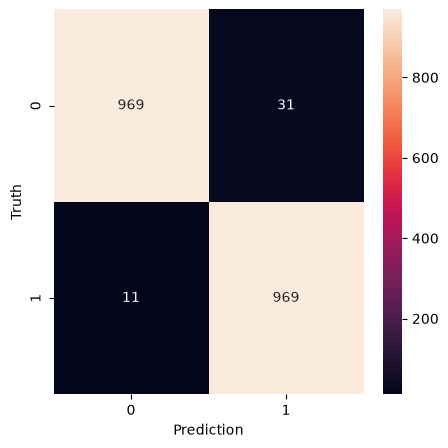

In [33]:
#finally print the confusion matrix for the best model
from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,y_pred)
print(cm)

from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

## **<font color='red'>Key Takeaways</font>**

**KNN model** which didn't perform well in the vectorization techniques like Bag of words, and TF-IDF due to very high dimensional vector space, **performed really well with glove vectors due to only 300-dimensional vectors and very good embeddings** (similar and related words have almost similar embeddings) for the given text data.

**MultinomialNB model** performed decently well but did not come into the top list because in the 300-dimensional vectors **we also have the negative values present**. The **Naive Bayes model does not fit the data if there are negative values**. So, **to overcome this** shortcoming, we have **used the Min-Max scaler to bring down all the values between 0 to 1.** In this process, there will be a possibility of variance and information loss among the data. But anyhow we got a decent recall and f1 scores.
